   diagnosis_code      vitals  prior_visits  readmitted
0               7  110.825081             2           0
1               4   83.064223             2           0
2               8   92.132196             2           0
3               5  107.340618             0           0
4               7   81.668083             3           1
ROC-AUC Score: 0.964265078447931


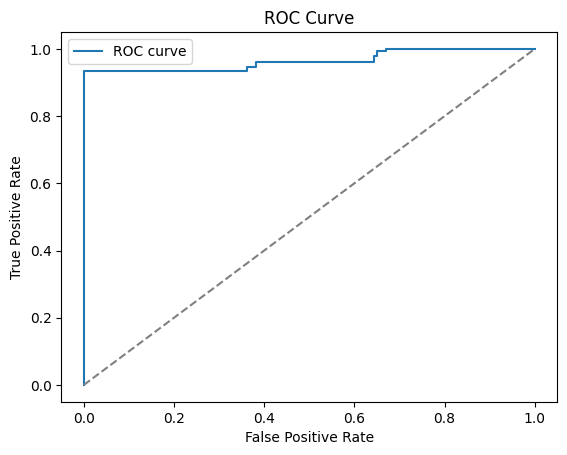

In [1]:
# Step 1: Install libraries (run in terminal or notebook if missing)
# pip install scikit-learn matplotlib pandas numpy

# Step 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 3: Synthetic dataset (1000 patients)
np.random.seed(42)

# Diagnosis codes (categorical → simple numbers)
diagnosis_code = np.random.randint(1, 10, 1000)

# Vitals
vitals = np.random.normal(100, 15, 1000)

# Prior visits
prior_visits = np.random.randint(0, 5, 1000)

# Target: readmitted (0/1)
# Rule:
readmitted = ((prior_visits > 2) | (vitals > 120)).astype(int)

# Step 4: DataFramedata = pd.DataFrame({
    'diagnosis_code': diagnosis_code,
    'vitals': vitals,
    'prior_visits': prior_visits,
    'readmitted': readmitted
})

print(data.head())  
# Step 5:
X = data[['diagnosis_code', 'vitals', 'prior_visits']]
y = data['readmitted']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 7: Logistic Regression model (L2 regularization)
model = LogisticRegression(penalty='l2', solver='liblinear')
model.fit(X_train, y_train)

# Step 8: Predictions (probabilities)
y_pred_prob = model.predict_proba(X_test)[:,1]

# Step 9: ROC-AUC score
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", auc)

# Step 10: ROC curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
